# 14 Analysis DE

## 1. Imports, paths and user settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [10]:
# Project paths
PROJECT_ROOT = Path("/nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics")
RESULTS_DIR = PROJECT_ROOT / "results"
PB_DIR = RESULTS_DIR / "10_Pseudobulk_26donors"
DE_DIR = RESULTS_DIR / "13_DE_pseudobulk_26donors"

# Analysis levels and their available cell types
CELL_TYPES_BY_LEVEL = {
    'broad': ['Excitatory', 'Inhibitory', 'Glia', 'Vascular'],
    'glia_subtypes': ['Glia_Oligo', 'Glia_OPC', 'Glia_Micro', 'Glia_Astro'],
    'excitatory_subtypes': [
        'Ex_L5_PCP4_NXPH2',
        'Ex_L5_L6_THEMIS_NR4A2',
        'Ex_L5_L6_THEMIS_TMEM233',
        'Ex_L6_TLE4_MEGF11',
        'Ex_L6_TLE4_CCBE1',
    ],
}

DE_SUBDIR = {
    "broad": DE_DIR / "broad",
    "glia_subtypes": DE_DIR / "glia_subtypes",
    "excitatory_subtypes": DE_DIR / "excitatory_subtypes",
}

PB_SUBDIR = {
    "broad": PB_DIR / "broad",
    "glia_subtypes": PB_DIR / "glia_subtypes",
    "excitatory_subtypes": PB_DIR / "excitatory_subtypes",
}

# Convenience map: cell type -> analysis level
CELLTYPE_TO_LEVEL = {
    cell_type: level
    for level, cell_types in CELL_TYPES_BY_LEVEL.items()
    for cell_type in cell_types
}

# Disease comparisons available from the DE notebook
COMPARISONS = ["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"]

PADJ_CUTOFF = 0.1
LFC_CUTOFF = 0.5


## 2. Small utilities

In [4]:
def match_genes(genes, available_genes):
    """Return available gene symbols matching the requested symbols, ignoring case."""
    lookup = {str(g).upper(): str(g) for g in available_genes}
    matched = [lookup[g.upper()] for g in map(str, genes) if g.upper() in lookup]
    missing = [g for g in genes if str(g).upper() not in lookup]
    return list(dict.fromkeys(matched)), missing


def de_path(cell_type, comparison):
    level = CELLTYPE_TO_LEVEL[cell_type]
    return DE_SUBDIR[level] / f"{cell_type}_{comparison}.csv"


def pb_paths(cell_type):
    level = CELLTYPE_TO_LEVEL[cell_type]
    return (
        PB_SUBDIR[level] / f"{cell_type}_counts.csv",
        PB_SUBDIR[level] / f"{cell_type}_meta.csv",
    )


def load_de(cell_type, comparison):
    path = de_path(cell_type, comparison)
    if not path.exists():
        raise FileNotFoundError(f"DE file not found: {path}")
    df = pd.read_csv(path)
    df["gene"] = df["gene"].astype(str)
    df["cell_type"] = cell_type
    df["comparison"] = comparison
    return df


def load_pseudobulk(cell_type):
    counts_path, meta_path = pb_paths(cell_type)
    if not counts_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Pseudobulk files not found for {cell_type}: {counts_path}, {meta_path}")

    counts = pd.read_csv(counts_path, index_col=0)
    meta = pd.read_csv(meta_path)

    if "sample" in meta.columns:
        meta = meta.set_index("sample")

    counts.index = counts.index.astype(str)
    counts.columns = counts.columns.astype(str)
    meta.index = meta.index.astype(str)
    meta = meta.loc[counts.index].copy()
    meta["cell_type"] = cell_type
    return counts, meta


def logcpm(counts):
    return np.log1p(counts.div(counts.sum(axis=1), axis=0) * 1e6)


def display_comparison(comparison):
    baseline, test = comparison.split("_vs_")
    return f"{test} vs {baseline}"


## 3. Donor-level expression of selected genes

In [11]:
pd.DataFrame([
    {"broad_class": level, "cell_type": cell_type}
    for level, cell_types in CELL_TYPES_BY_LEVEL.items()
    for cell_type in cell_types
])

,broad_class,cell_type
0,broad,Excitatory
1,broad,Inhibitory
2,broad,Glia
3,broad,Vascular
4,glia_subtypes,Glia_Oligo
5,glia_subtypes,Glia_OPC
6,glia_subtypes,Glia_Micro
7,glia_subtypes,Glia_Astro
8,excitatory_subtypes,Ex_L5_PCP4_NXPH2
9,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2


In [12]:
# Gene panels for quick exploration
GENE_PANELS = {
    "CSW": ["C9orf72", "SMCR8", "WDR41"],
    "ULK_complex": ["ULK1", "ULK2", "RB1CC1", "ATG13", "ATG101"],
    "autophagy_receptors": ["SQSTM1", "OPTN", "CALCOCO2", "TAX1BP1", "NBR1"],
    "mitophagy": ["PINK1", "PRKN", "BNIP3", "BNIP3L", "FUNDC1", "PHB2", "BCL2L13", "FKBP8"],
    "inflammation": ["CGAS", "STING1", "TBK1", "IRF3"],
}

# Main examples used below
SELECTED_CELL_TYPES = [
    "Ex_L5_PCP4_NXPH2",
    "Ex_L5_L6_THEMIS_NR4A2",
    "Ex_L5_L6_THEMIS_TMEM233",
    "Ex_L6_TLE4_MEGF11",
    "Ex_L6_TLE4_CCBE1",
    "Glia_Micro",
]

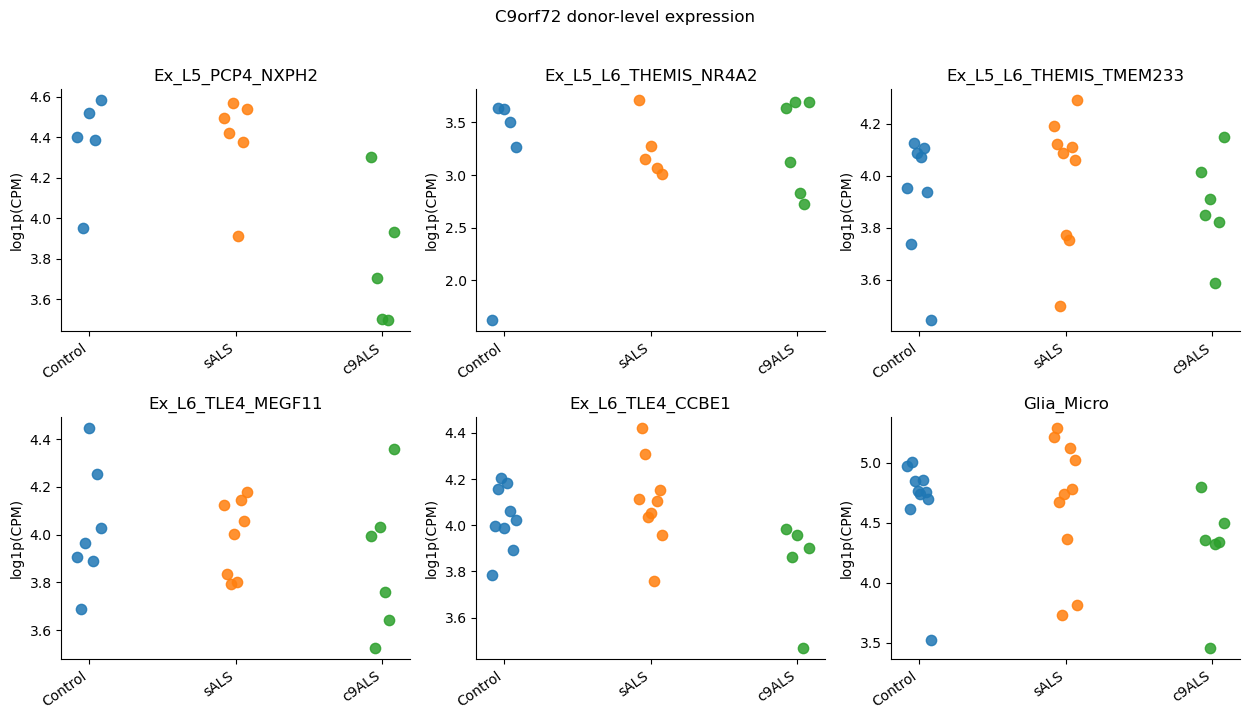

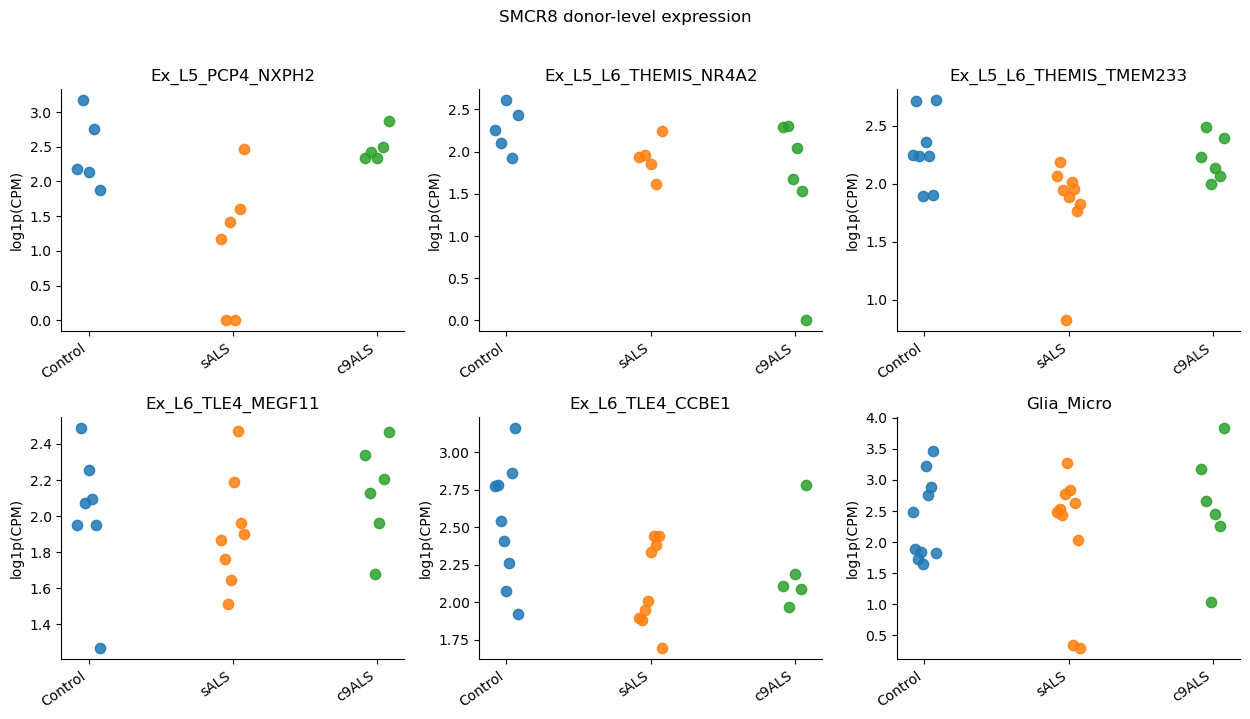

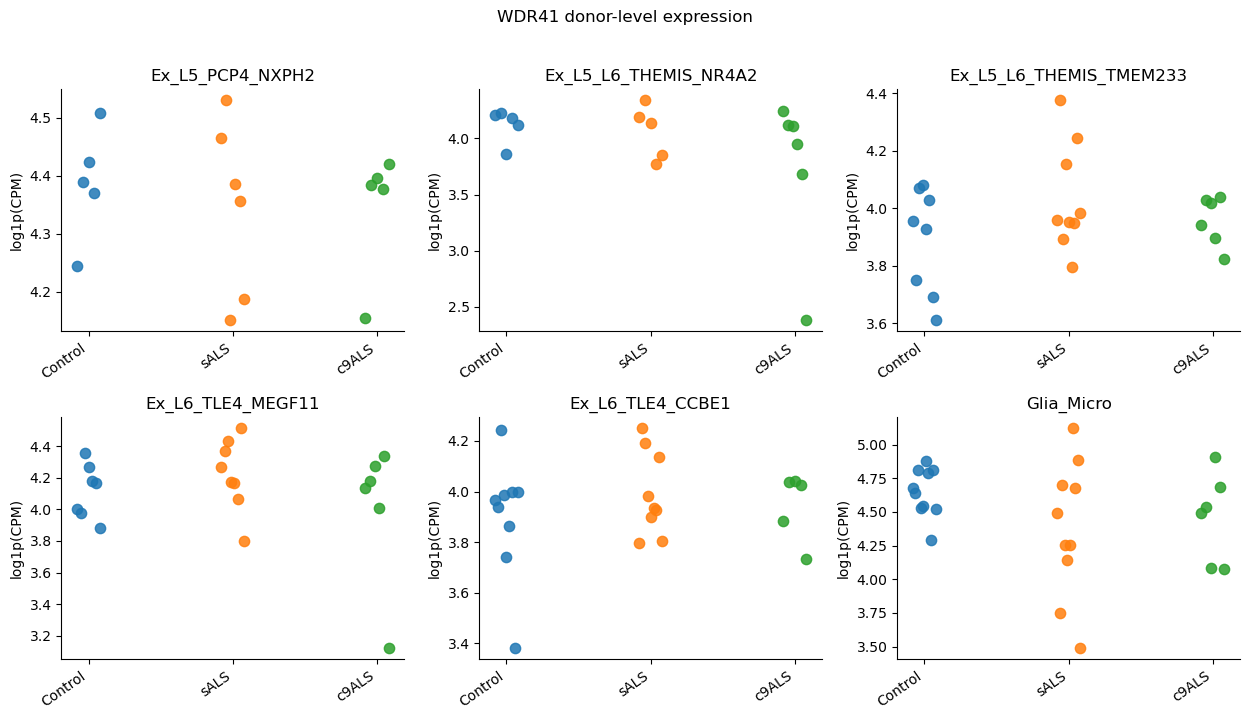

In [19]:
genes_to_plot = GENE_PANELS["CSW"]
cell_types_to_plot = SELECTED_CELL_TYPES

condition_order = ["Control", "sALS", "c9ALS"]

for gene in genes_to_plot:
    n_cols = 3
    n_rows = int(np.ceil(len(cell_types_to_plot) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.5 * n_rows), squeeze=False)
    axes = axes.ravel()

    for ax, cell_type in zip(axes, cell_types_to_plot):
        counts, meta = load_pseudobulk(cell_type)
        matched, missing = match_genes([gene], counts.columns)

        if missing:
            ax.set_title(f"{cell_type}\n{gene} not found")
            ax.axis("off")
            continue

        gene_symbol = matched[0]
        expr = logcpm(counts)[gene_symbol]
        plot_df = meta.copy()
        plot_df["expression"] = expr

        present_conditions = [c for c in condition_order if c in set(plot_df["condition"].astype(str))]
        for i, condition in enumerate(present_conditions):
            sub = plot_df[plot_df["condition"].astype(str) == condition]
            jitter = np.linspace(-0.08, 0.08, len(sub)) if len(sub) > 1 else [0]
            ax.scatter(np.array([i] * len(sub)) + jitter, sub["expression"], s=55, alpha=0.85)

        ax.set_title(cell_type)
        ax.set_xticks(range(len(present_conditions)))
        ax.set_xticklabels(present_conditions, rotation=35, ha="right")
        ax.set_ylabel("log1p(CPM)")
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[len(cell_types_to_plot):]:
        ax.axis("off")

    fig.suptitle(f"{gene} donor-level expression", y=1.02)
    fig.tight_layout()
    plt.show()


## 4. Volcano plot for one DE result

In [20]:
de_raw = load_de("Glia_Micro", "Control_vs_c9ALS")
de_raw[de_raw["gene"].str.upper() == "SMCR8"]

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,comparison
24564,SMCR8,5.943447,0.337563,0.567127,0.595216,0.551699,0.924612,Glia_Micro,Control_vs_c9ALS


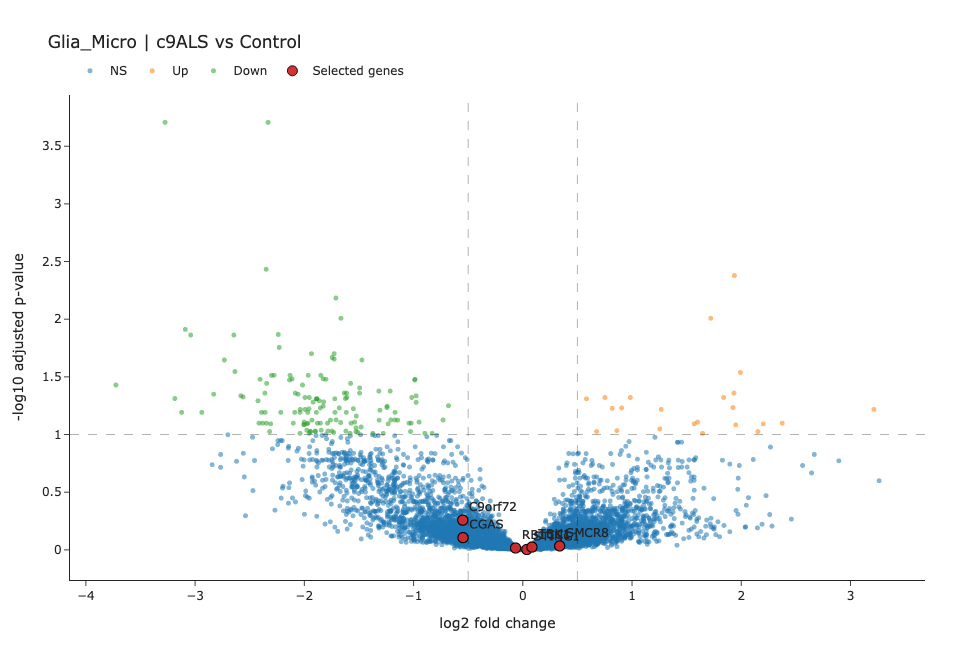

In [24]:
cell_type = "Glia_Micro"
comparison = "Control_vs_c9ALS"
highlight_genes = ["C9orf72", "SMCR8", "STING1", "CGAS", "TBK1", "RB1CC1"]
# highlight_genes = ["C9orf72", "SMCR8"]

de = load_de(cell_type, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()
de["neglog10_padj"] = -np.log10(de["padj"].clip(lower=1e-300))
de["direction"] = "NS"
de.loc[(de["padj"] < PADJ_CUTOFF) & (de["log2FoldChange"] > LFC_CUTOFF), "direction"] = "Up"
de.loc[(de["padj"] < PADJ_CUTOFF) & (de["log2FoldChange"] < -LFC_CUTOFF), "direction"] = "Down"

matched, missing = match_genes(highlight_genes, de["gene"])
if missing:
    print("Missing highlight genes:", missing)
de["highlight"] = de["gene"].isin(matched)

fig = go.Figure()

# Background genes, split into NS/Up/Down for clear legend and filtering.
for direction in ["NS", "Up", "Down"]:
    sub = de[(de["direction"] == direction) & (~de["highlight"])]
    if sub.empty:
        continue
    fig.add_trace(
        go.Scattergl(
            x=sub["log2FoldChange"],
            y=sub["neglog10_padj"],
            mode="markers",
            name=direction,
            marker=dict(size=5, opacity=0.55),
            text=sub["gene"],
            customdata=np.stack([
                sub["padj"],
                sub["pvalue"] if "pvalue" in sub.columns else pd.Series(np.nan, index=sub.index),
                sub["baseMean"] if "baseMean" in sub.columns else pd.Series(np.nan, index=sub.index),
            ], axis=1),
            hovertemplate=(
                "Gene: %{text}<br>"
                "log2FC: %{x:.3f}<br>"
                "-log10(padj): %{y:.3f}<br>"
                "padj: %{customdata[0]:.3g}<br>"
                "pvalue: %{customdata[1]:.3g}<br>"
                "baseMean: %{customdata[2]:.3g}<extra></extra>"
            ),
        )
    )

# Highlight selected genes with labels.
hits = de[de["highlight"]]
if not hits.empty:
    fig.add_trace(
        go.Scattergl(
            x=hits["log2FoldChange"],
            y=hits["neglog10_padj"],
            mode="markers+text",
            name="Selected genes",
            marker=dict(size=10, opacity=0.95, line=dict(width=1, color="black")),
            text=hits["gene"],
            textposition="top right",
            customdata=np.stack([
                hits["padj"],
                hits["pvalue"] if "pvalue" in hits.columns else pd.Series(np.nan, index=hits.index),
                hits["baseMean"] if "baseMean" in hits.columns else pd.Series(np.nan, index=hits.index),
            ], axis=1),
            hovertemplate=(
                "Gene: %{text}<br>"
                "log2FC: %{x:.3f}<br>"
                "-log10(padj): %{y:.3f}<br>"
                "padj: %{customdata[0]:.3g}<br>"
                "pvalue: %{customdata[1]:.3g}<br>"
                "baseMean: %{customdata[2]:.3g}<extra></extra>"
            ),
        )
    )

fig.add_vline(x=LFC_CUTOFF, line_dash="dash", line_color="black", line_width=1)
fig.add_vline(x=-LFC_CUTOFF, line_dash="dash", line_color="black", line_width=1)
fig.add_hline(y=-np.log10(PADJ_CUTOFF), line_dash="dash", line_color="black", line_width=1)

fig.update_layout(
    title=f"{cell_type} | {display_comparison(comparison)}",
    xaxis_title="log2 fold change",
    yaxis_title="-log10 adjusted p-value",
    template="simple_white",
    width=900,
    height=650,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=70, r=30, t=95, b=70),
)

fig.show()

## 5. log2FC heatmap for selected genes across cell types and comparisons

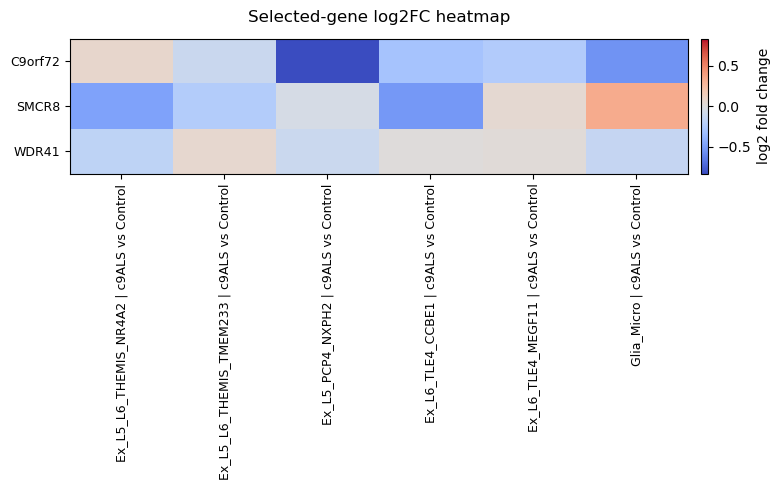

In [25]:
SELECTED_CELL_TYPES = [
    "Ex_L5_PCP4_NXPH2",
    "Ex_L5_L6_THEMIS_NR4A2",
    "Ex_L5_L6_THEMIS_TMEM233",
    "Ex_L6_TLE4_MEGF11",
    "Ex_L6_TLE4_CCBE1",
    "Glia_Micro",
]
cell_types = SELECTED_CELL_TYPES
comparisons = ["Control_vs_c9ALS"]
# genes = GENE_PANELS["inflammation"]
genes = GENE_PANELS["CSW"]

rows = []

for cell_type in cell_types:
    for comparison in comparisons:
        path = de_path(cell_type, comparison)

        if not path.exists():
            print("Missing DE file, skipped:", path.name)
            continue

        de = load_de(cell_type, comparison)
        matched, missing = match_genes(genes, de["gene"])

        if missing:
            print(f"{cell_type} {comparison}: missing genes:", missing)

        sub = de[de["gene"].isin(matched)].copy()

        if sub.empty:
            print(f"No matched genes for {cell_type} {comparison}; skipped.")
            continue

        sub["label"] = f"{cell_type} | {display_comparison(comparison)}"
        rows.append(sub[["gene", "label", "log2FoldChange"]])

heatmap_df = pd.concat(rows, ignore_index=True)

mat = (
    heatmap_df
    .pivot_table(
        index="gene",
        columns="label",
        values="log2FoldChange",
        aggfunc="first",
    )
    .reindex(genes)
    .dropna(how="all")
)
n_genes = mat.shape[0]
n_cols = mat.shape[1]

fig_width = max(8, 0.7 * n_cols)
fig_height = max(5, 0.8 * n_genes)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

vmax = np.nanmax(np.abs(mat.values))
if vmax == 0 or np.isnan(vmax):
    vmax = 1

im = ax.imshow(
    mat.values,
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
    cmap="coolwarm"
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(mat.columns, rotation=90, ha="center", fontsize=9)

ax.set_yticks(np.arange(n_genes))
ax.set_yticklabels(mat.index, fontsize=9)

ax.set_title("Selected-gene log2FC heatmap", pad=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("log2 fold change")

plt.tight_layout()
plt.show()

## 6. Summarise one gene across cell types and comparisons

In [26]:
gene = "C9orf72"
cell_types = ["Excitatory", "Glia_Micro"]

summary_rows = []
for cell_type in cell_types:
    for comparison in COMPARISONS:
        de = load_de(cell_type, comparison)
        matched, _ = match_genes([gene], de["gene"])
        if not matched:
            continue
        row = de[de["gene"] == matched[0]].copy()
        row["comparison_display"] = display_comparison(comparison)
        summary_rows.append(row)

gene_summary = pd.concat(summary_rows, ignore_index=True)
cols = [c for c in ["cell_type", "comparison", "comparison_display", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in gene_summary.columns]
gene_summary[cols].sort_values(["cell_type", "comparison"])


,cell_type,comparison,comparison_display,gene,log2FoldChange,padj,pvalue,baseMean
0,Excitatory,Control_vs_c9ALS,c9ALS vs Control,C9orf72,-0.121239,0.841863,0.495530,1112.460065
1,Excitatory,Control_vs_sALS,sALS vs Control,C9orf72,0.085332,0.719692,0.508778,873.807622
2,Excitatory,sALS_vs_c9ALS,c9ALS vs sALS,C9orf72,-0.211037,0.527588,0.187359,1048.580964
3,Glia_Micro,Control_vs_c9ALS,c9ALS vs Control,C9orf72,-0.549774,0.553026,0.080080,42.296310
4,Glia_Micro,Control_vs_sALS,sALS vs Control,C9orf72,0.183652,0.879825,0.524986,45.506940
5,Glia_Micro,sALS_vs_c9ALS,c9ALS vs sALS,C9orf72,-0.720574,0.999858,0.056467,34.579249


## 7. Top DE hits for one cell type/comparison

In [27]:
cell_type = "Glia_Micro"
comparison = "Control_vs_c9ALS"

de = load_de(cell_type, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()

top_hits = (
    de[(de["padj"] < PADJ_CUTOFF) & (de["log2FoldChange"].abs() > LFC_CUTOFF)]
    .sort_values(["padj", "baseMean"], ascending=[True, False])
    .head(30)
)

cols = [c for c in ["cell_type", "comparison", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in top_hits.columns]
top_hits[cols]


,cell_type,comparison,gene,log2FoldChange,padj,pvalue,baseMean
15780,Glia_Micro,Control_vs_c9ALS,ABCA2,-2.331866,0.000196,4.035572e-08,42.469019
3858,Glia_Micro,Control_vs_c9ALS,LRP2,-3.274729,0.000196,2.889513e-08,22.173765
21114,Glia_Micro,Control_vs_c9ALS,LINC00609,-2.349652,0.003689,1.136965e-06,46.000612
11150,Glia_Micro,Control_vs_c9ALS,RPA3,1.937087,0.004179,1.717202e-06,7.209075
5310,Glia_Micro,Control_vs_c9ALS,CLDND1,-1.711232,0.006550,3.364048e-06,57.485936
18704,Glia_Micro,Control_vs_c9ALS,LINC00844,-1.664808,0.009814,6.048657e-06,12.170319
22526,Glia_Micro,Control_vs_c9ALS,ENSG00000259678,1.720627,0.009815,7.057243e-06,44.030059
13494,Glia_Micro,Control_vs_c9ALS,ENSG00000289591,-3.089784,0.012254,1.007002e-05,19.895674
26517,Glia_Micro,Control_vs_c9ALS,PIEZO2,-2.238561,0.013566,1.254201e-05,31.789879
7733,Glia_Micro,Control_vs_c9ALS,SORCS2,-2.644906,0.013715,1.549724e-05,18.473853
